In [30]:
## Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error

In [ ]:
!pip install optuna

In [31]:
import optuna

In [32]:
## Path

path  = 'data/'

In [33]:
## Data

train = pd.read_csv(path + 'train.csv')

test = pd.read_csv(path + 'test.csv')

In [34]:
## Train Data Overview

train.info()

train.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB


,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [35]:
## Test Data Overview

test.info()

test.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          250000 non-null  int64  
 1   Sex         250000 non-null  object 
 2   Age         250000 non-null  int64  
 3   Height      250000 non-null  float64
 4   Weight      250000 non-null  float64
 5   Duration    250000 non-null  float64
 6   Heart_Rate  250000 non-null  float64
 7   Body_Temp   250000 non-null  float64
dtypes: float64(5), int64(2), object(1)
memory usage: 15.3+ MB


,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,750000,male,45,177.0,81.0,7.0,87.0,39.8
1,750001,male,26,200.0,97.0,20.0,101.0,40.5
2,750002,female,29,188.0,85.0,16.0,102.0,40.4
3,750003,female,39,172.0,73.0,20.0,107.0,40.6
4,750004,female,30,173.0,67.0,16.0,94.0,40.5


In [36]:
## Train Column Data Information

train.describe()

,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
std,216506.495284,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
min,0.000000,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,187499.750000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,374999.500000,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,562499.250000,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,749999.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [37]:
## Test Column Data Information

test.describe()

,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,874999.500000,41.452464,174.725624,75.147712,15.415428,95.479084,40.036093
std,72168.927986,15.177769,12.822039,13.979513,8.349133,9.450161,0.778448
min,750000.000000,20.000000,127.000000,39.000000,1.000000,67.000000,37.100000
25%,812499.750000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000
50%,874999.500000,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000
75%,937499.250000,52.000000,185.000000,87.000000,23.000000,103.000000,40.600000
max,999999.000000,79.000000,219.000000,126.000000,30.000000,128.000000,41.500000


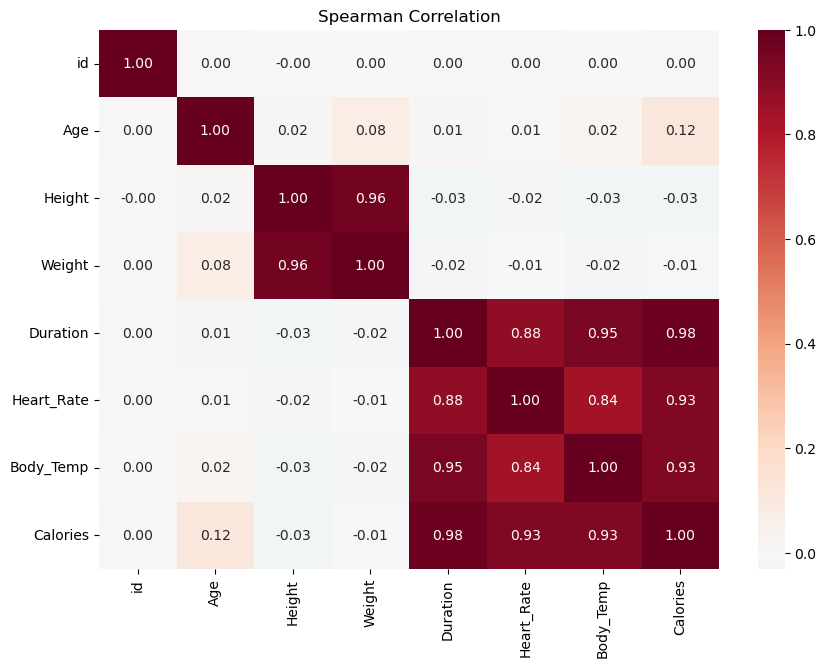

In [38]:
## Train Correlation

num_cols = train.select_dtypes(include = ["int64", "float64"]).columns.tolist()
num_cols.remove("Calories")

corr = train[num_cols + ["Calories"]].corr(method="spearman")

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Spearman Correlation")
plt.show()



In [39]:
## Splitting Data

X = train[['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']]
y = train['Calories']


In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
## Model Hyperparameters

def rmsle(y_true, y_pred):
    y_pred = np.maximum(0, y_pred)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

def objective(trial):
    
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_int('max_depth', 3, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    score = rmsle(y_test, preds)
    return score  


In [45]:
## Optuna Optimization

study = optuna.create_study(direction='minimize')

study.optimize(objective, n_trials=100)

print("Best hyperparameters:", study.best_params)
print("Best RMSLE:", study.best_value)

[I 2025-05-13 10:09:42,477] A new study created in memory with name: no-name-62605855-143b-4fe3-98d4-44f9df914df8
[I 2025-05-13 10:10:07,022] Trial 0 finished with value: 0.08135610773286586 and parameters: {'n_estimators': 84, 'max_depth': 12, 'min_samples_split': 15, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.08135610773286586.
[I 2025-05-13 10:12:38,958] Trial 1 finished with value: 0.0711017599755755 and parameters: {'n_estimators': 335, 'max_depth': 19, 'min_samples_split': 6, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.0711017599755755.
[I 2025-05-13 10:15:18,533] Trial 2 finished with value: 0.07453506758556468 and parameters: {'n_estimators': 394, 'max_depth': 14, 'min_samples_split': 11, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 1 with value: 0.0711017599755755.
[I 2025-05-13 10:17:22,690] Trial 3 finished with value: 0.06987190969566988 and parameters: {'n_estimators': 271, 'max_depth': 2

KeyboardInterrupt: 

In [46]:
## Optimized Model

opt_rf_model = RandomForestRegressor(n_estimators=80,
        max_depth=18,
        min_samples_split=19,
        min_samples_leaf=6,
        max_features=None,
        random_state=42)

nonOP_rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [47]:
## Fitting Model

opt_rf_model.fit(X_train, y_train)

nonOP_rf_model.fit(X_train, y_train) 

RandomForestRegressor(random_state=42)

In [48]:
## Make Predictions

train_predictions = opt_rf_model.predict(X_test)

nonOP_train_predictions = nonOP_rf_model.predict(X_test)

In [49]:
## Root Mean Squared Logarithmic Error

msle = mean_squared_log_error(y_test, train_predictions)

rmsle = np.sqrt(msle)

print("RMSLE:", rmsle)

nonOP_msle = mean_squared_log_error(y_test, nonOP_train_predictions)

nonOP_rmsle = np.sqrt(nonOP_msle)

print("NON Optimized RMSLE:", nonOP_rmsle)

RMSLE: 0.06905117617716436
NON Optimized RMSLE: 0.0717085213294003


In [50]:
# Test Data

test_X = test[['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']]

In [51]:
test_predictions = opt_rf_model.predict(test_X)

In [52]:
test_predictions = np.maximum(0, test_predictions)

In [53]:
# Output CSV

output_df = pd.DataFrame({
    'id': test['id'],
    'Calories': test_predictions
})


output_df.to_csv('submission.csv', index=False)

In [54]:
# Non OP Test Data

nonOP_test_predictions = nonOP_rf_model.predict(test_X)

nonOP_test_predictions = np.maximum(0, nonOP_test_predictions)

In [55]:
# Non OP Output CSV

nonOP_output_df = pd.DataFrame({
    'id': test['id'],
    'Calories': nonOP_test_predictions
})

nonOP_output_df.to_csv('nonOPsubmission.csv', index=False)